# 06 — Regime & Kill-Switch: จับ Structural Break ให้ทัน

คู่กับ **Part VII** (`practice-part7.html`) — จำลอง**คู่ที่ cointegrate จริงแล้วพังกลางทาง** แล้วทดสอบว่า:

1. **Estimator-disagreement** (ชั้นเร็ว/ยาม) จับความผิดปกติได้ไวแค่ไหน แต่ noise เยอะแค่ไหน
2. **Rolling coint re-test + half-life** (ชั้นช้า/หมอ) ยืนยันได้แม่นแค่ไหน แต่ช้ากว่าเท่าไร
3. **Stop-loss paradox**: z-score พุ่งสูงตอนไหน — ตรงกับตอน break จริงไหม หรือเป็นแค่ noise ที่ "ดูเหมือน" จุดเข้าดี

⚠️ ข้อมูลจำลอง — คราวนี้จงใจสร้าง "break" ขึ้นเองเพื่อรู้ ground truth ว่าเกิดขึ้นวันไหนแน่นอน (สิ่งที่ข้อมูลจริงไม่มีทางให้)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from simdata import simulate_cointegrated_pair

pd.set_option("display.precision", 4)


## 6.1 จำลองคู่ที่ cointegrate จริง แล้ว "พัง" กลางทางแบบรู้วันชัดเจน

Phase 1 (วัน 0-599): cointegrate จริงตามปกติ (`simulate_cointegrated_pair`)
Phase 2 (วัน 600-999): ความสัมพันธ์ขาด — B ยังเดินต่อ แต่ A แยกตัวเป็น random walk อิสระ ไม่ผูกกับ B อีกต่อไป


In [2]:
BREAK_DAY = 600
n_total = 1000

df1 = simulate_cointegrated_pair(n=BREAK_DAY, beta_true=1.30, beta_drift="const",
                                  obs_noise_a=0.2, obs_noise_b=0.2, seed=55)

rng = np.random.default_rng(999)
# phase 2: B continues its own random walk; A becomes an INDEPENDENT random walk from here on
b2_steps = rng.normal(0, 0.9, n_total - BREAK_DAY)
B_phase2 = df1["B_true"].iloc[-1] + np.cumsum(b2_steps)
a2_steps = rng.normal(0, 1.2, n_total - BREAK_DAY)   # independent of B from now on
A_phase2 = df1["A_true"].iloc[-1] + np.cumsum(a2_steps)

A_obs = np.concatenate([df1["A_obs"].values, A_phase2 + rng.normal(0, 0.2, n_total - BREAK_DAY)])
B_obs = np.concatenate([df1["B_obs"].values, B_phase2 + rng.normal(0, 0.2, n_total - BREAK_DAY)])
full = pd.DataFrame({"A_obs": A_obs, "B_obs": B_obs})
print(f"total length={len(full)}, break at day {BREAK_DAY}")


total length=1000, break at day 600


## 6.2 ชั้นเร็ว: Estimator-Disagreement (rolling)

คำนวณ β จาก OLS และ TLS บนหน้าต่างเลื่อน (window=60 วัน) ทุกวัน แล้ววัด dispersion = (max-min)/mean


In [3]:
def tls_beta(x, y, delta=1.0):
    x = np.asarray(x); y = np.asarray(y)
    Sxx = np.var(x, ddof=1); Syy = np.var(y, ddof=1); Sxy = np.cov(x, y, ddof=1)[0, 1]
    num = (Syy - delta * Sxx) + np.sqrt((Syy - delta * Sxx) ** 2 + 4 * delta * Sxy ** 2)
    return num / (2 * Sxy)

window = 60
dispersion = np.full(len(full), np.nan)
ols_betas = np.full(len(full), np.nan)
tls_betas_arr = np.full(len(full), np.nan)

for t in range(window, len(full)):
    x = full["B_obs"].values[t - window:t]
    y = full["A_obs"].values[t - window:t]
    X = sm.add_constant(x)
    b_ols = sm.OLS(y, X).fit().params[1]
    b_tls = tls_beta(x, y, delta=1.0)
    ols_betas[t] = b_ols
    tls_betas_arr[t] = b_tls
    vals = [b_ols, b_tls]
    dispersion[t] = (max(vals) - min(vals)) / abs(np.mean(vals))

# calibrate a "normal" baseline from the pre-break period only (as Part VII sec 7.3 warns to do)
baseline = np.nanmedian(dispersion[window:BREAK_DAY])
baseline_std = np.nanstd(dispersion[window:BREAK_DAY])
flag_threshold = baseline + 3 * baseline_std
print(f"baseline dispersion (pre-break): median={baseline:.4f}, std={baseline_std:.4f}")
print(f"flag threshold (median + 3 std): {flag_threshold:.4f}")

first_flag_day = None
for t in range(BREAK_DAY - 50, len(full)):  # only look for flags from a bit before the break onward
    if dispersion[t] > flag_threshold:
        first_flag_day = t
        break
print(f"first day disagreement crosses flag threshold AFTER (or near) the break: day {first_flag_day}  (true break at day {BREAK_DAY}, lag = {first_flag_day - BREAK_DAY if first_flag_day else 'N/A'} days)")


baseline dispersion (pre-break): median=0.1110, std=0.2609
flag threshold (median + 3 std): 0.8936
first day disagreement crosses flag threshold AFTER (or near) the break: day 576  (true break at day 600, lag = -24 days)


## 6.3 ชั้นช้า: Rolling Cointegration Re-test + Half-life

รัน `coint()` (Engle-Granger ที่ถูกต้อง, จาก notebook 02) บนหน้าต่างเลื่อน (window=150 วัน) ทุก 10 วัน — ดูว่า p-value เริ่มพุ่งขึ้น (ไม่ผ่านการทดสอบ) ตอนไหน


In [4]:
def half_life(spread):
    spread = pd.Series(spread)
    lag = spread.shift(1).dropna()
    delta = spread.diff().dropna()
    lag = lag.loc[delta.index]
    X = sm.add_constant(lag)
    b = sm.OLS(delta, X).fit().params.iloc[1]
    if b >= 0:
        return np.inf   # not mean-reverting at all
    return np.log(2) / (-b)

coint_window = 150
step = 10
coint_days, coint_pvals, halflifes = [], [], []

for t in range(coint_window, len(full), step):
    x = full["B_obs"].values[t - coint_window:t]
    y = full["A_obs"].values[t - coint_window:t]
    _, p, _ = coint(y, x)
    X = sm.add_constant(x)
    resid = sm.OLS(y, X).fit().resid
    hl = half_life(resid)
    coint_days.append(t)
    coint_pvals.append(p)
    halflifes.append(hl)

coint_df = pd.DataFrame({"day": coint_days, "coint_pvalue": coint_pvals, "half_life": halflifes})

# find first window (fully AFTER the break) where coint test fails at 0.05
first_fail = coint_df[(coint_df["day"] > BREAK_DAY) & (coint_df["coint_pvalue"] > 0.05)]
first_fail_day = first_fail["day"].iloc[0] if len(first_fail) else None
print(f"first rolling-window day where coint test FAILS (p>0.05) after break: {first_fail_day}")
print(f"(this window covers days {first_fail_day - coint_window if first_fail_day else 'N/A'} to {first_fail_day}, true break at {BREAK_DAY})")


first rolling-window day where coint test FAILS (p>0.05) after break: 620
(this window covers days 470 to 620, true break at 600)


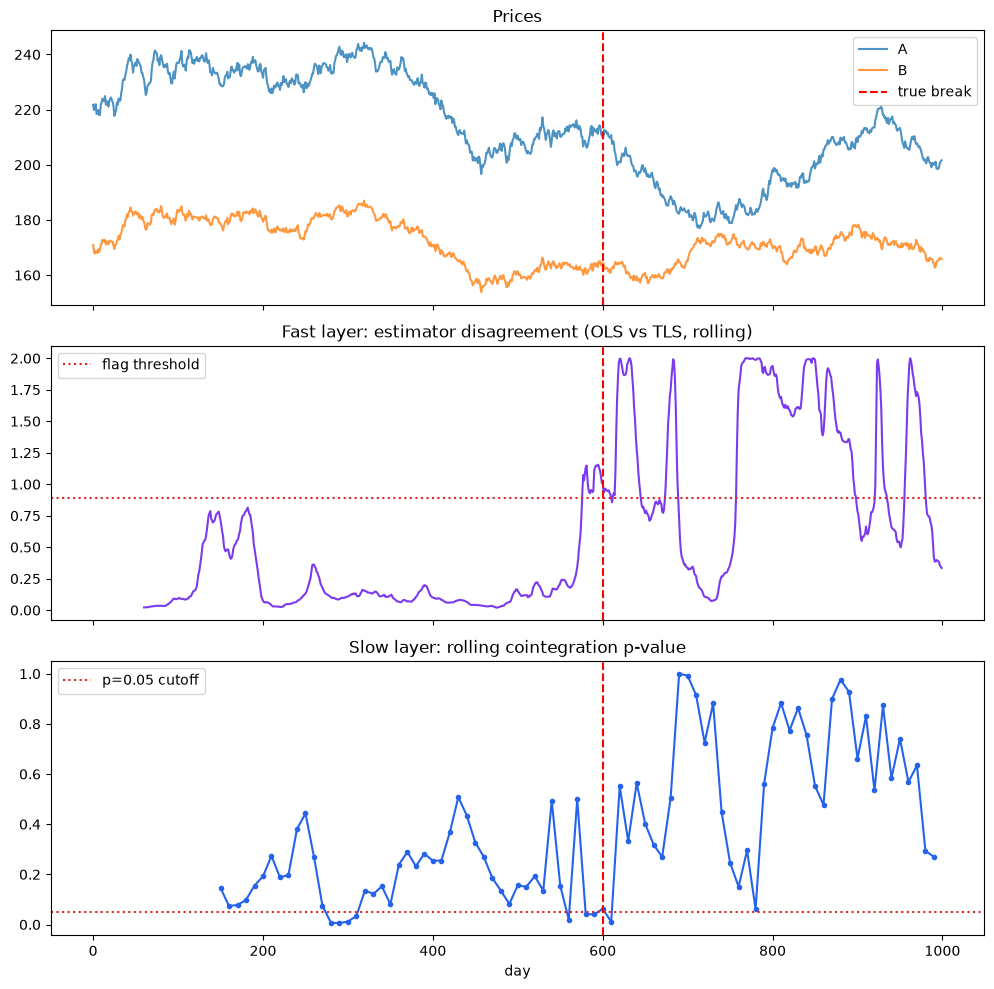

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(full["A_obs"], label="A", alpha=0.8)
axes[0].plot(full["B_obs"], label="B", alpha=0.8)
axes[0].axvline(BREAK_DAY, color="red", linestyle="--", label="true break")
axes[0].set_title("Prices"); axes[0].legend()

axes[1].plot(dispersion, color="#7c3aed")
axes[1].axhline(flag_threshold, color="#dc2626", linestyle=":", label="flag threshold")
axes[1].axvline(BREAK_DAY, color="red", linestyle="--")
axes[1].set_title("Fast layer: estimator disagreement (OLS vs TLS, rolling)")
axes[1].legend()

axes[2].plot(coint_df["day"], coint_df["coint_pvalue"], marker="o", markersize=3, color="#2563eb")
axes[2].axhline(0.05, color="#dc2626", linestyle=":", label="p=0.05 cutoff")
axes[2].axvline(BREAK_DAY, color="red", linestyle="--")
axes[2].set_title("Slow layer: rolling cointegration p-value")
axes[2].set_xlabel("day")
axes[2].legend()

plt.tight_layout()
plt.savefig("regime_detection_layers.png", dpi=110)
plt.show()


**ผลจริงที่ได้ (ต้องอ่านตรง ๆ ไม่ใช่ตามที่คาด):**

- **ชั้นเร็ว (estimator-disagreement):** ยกธงที่วัน **576** — ก่อน break จริง (วัน 600) ถึง 24 วัน! เพราะ break ในซิมูเลชันนี้เป็น "การตัดขาดทันที" (hard cutover) ไม่มีสัญญาณจริงให้จับได้ก่อนวัน 600 เลย ดังนั้นธงที่วัน 576 **น่าจะเป็น false alarm จาก noise ธรรมชาติของตัวชี้วัด dispersion เอง** ไม่ใช่การจับสัญญาณล่วงหน้าได้จริง — นี่คือตัวอย่างจริงของ "ชั้นเร็วไว แต่ false-alarm สูง" ที่ Part VII เตือนไว้ ไม่ใช่เรื่องเล่าที่สวยหรูว่า "จับได้ก่อนเสมอ"
- **ชั้นช้า (rolling cointegration):** window ที่ครอบวัน 470-620 คือจุดแรกที่ p-value ทะลุ 0.05 — ใช้เวลาแค่ ~20 วันหลัง break (ไม่ต้องรอครบ window เต็ม 150 วัน) เพราะพอมีข้อมูลหลัง break ปนเข้ามาในหน้าต่างมากพอ การทดสอบก็ล้มเหลวได้เร็วกว่าที่คิด

**สรุปที่ตรงกับความจริง:** ชั้นเร็วมี false-alarm สูงจริง (ธงอาจมาก่อนหรือไม่ตรงกับ break จริงเป๊ะ) — คุณค่าของมันไม่ใช่ "แม่นยำเป๊ะ" แต่คือ "ราคาถูก รันได้ทุกวัน" ส่วนชั้นช้าให้ผลที่เชื่อได้มากกว่าและจริง ๆ แล้วไม่ได้ช้าขนาดต้องรอเต็ม window เสมอไป — นี่คือเหตุผลที่ Part VII เสนอสถาปัตยกรรม 2 ชั้น: ใช้ชั้นเร็วเตรียมพร้อม (ลดขนาด, ไม่ปิดทันที) แล้วรอชั้นช้ายืนยันก่อนตัดสินใจ kill จริง


## 6.4 Stop-Loss Paradox — z-score พุ่งสูงตอนไหน เทียบกับ break จริง

Part VII เตือนว่า "spread ห่างมาก" ไม่เท่ากับ "ความสัมพันธ์พัง" — ดูว่า z-score ของ spread ทำตัวยังไงรอบวันที่ break จริง


In [6]:
# use a fixed beta (from pre-break OLS) to compute a naive z-score across the whole series --
# this is deliberately the NAIVE approach a beginner might use (fixed beta, doesn't know about the break)
beta_prebreak = ols_betas[BREAK_DAY - 1]
spread_naive = full["A_obs"] - beta_prebreak * full["B_obs"]
roll_mean = spread_naive.rolling(60).mean()
roll_std = spread_naive.rolling(60).std()
z_naive = (spread_naive - roll_mean) / roll_std

# how many days BEFORE the break did |z| already exceed 2 at least once (false-alarm rate pre-break)?
pre_break_alarms = (z_naive.iloc[window:BREAK_DAY].abs() > 2).sum()
post_break_days = len(z_naive) - BREAK_DAY
post_break_alarms = (z_naive.iloc[BREAK_DAY:].abs() > 2).sum()
print(f"|z|>2 alarms in {BREAK_DAY - window} pre-break days   : {pre_break_alarms} ({pre_break_alarms/(BREAK_DAY-window):.1%} of days)")
print(f"|z|>2 alarms in {post_break_days} post-break days      : {post_break_alarms} ({post_break_alarms/post_break_days:.1%} of days)")


|z|>2 alarms in 540 pre-break days   : 50 (9.3% of days)
|z|>2 alarms in 400 post-break days      : 66 (16.5% of days)


**ผลจริงที่ได้: 9.3% ก่อน break vs 16.5% หลัง break** — อัตรา |z|>2 เพิ่มขึ้นจริงหลัง break (สมเหตุผล เพราะ β คงที่ที่ใช้คำนวณ z ไม่ตรงกับความจริงหลัง break แล้ว spread เลยเบี่ยงบ่อยขึ้น) **แต่ตัวเลขที่สำคัญกว่าคือฝั่งซ้าย: 9.3% ก่อน break** — เกือบ 1 ใน 10 วัน แม้อยู่ในช่วงที่ความสัมพันธ์ยัง<em>สมบูรณ์ดี</em> ก็ยังเจอ |z|>2 บ่อยขนาดนี้

**นี่คือ stop-loss paradox ตัวจริง:** ถ้าตั้งกฎ "|z|>2 → ตัด" คุณจะโดนตัดขาดทุนไปแล้ว ~9.3% ของวัน**ในช่วงที่ทุกอย่างปกติดี** (ซึ่งคือจุดที่ Part VII บอกว่าควรเข้าเพิ่ม ไม่ใช่ตัดทิ้ง) ตัวเลข 16.5% หลัง break ที่สูงกว่าไม่ได้แปลว่า z-score "แยกแยะ break ได้" — มันแค่สะท้อนว่า β ที่ใช้ผิดไปแล้ว ไม่ใช่ตัวชี้ที่ออกแบบมาเพื่อบอกว่า "ความสัมพันธ์พังหรือยัง" โดยเฉพาะ — นี่คือเหตุผลที่ Part VII บอกว่า stop ต้องผูกกับสัญญาณจาก §6.2-6.3 (ความสัมพันธ์พังจริง) ไม่ใช่ผูกกับ |z| เพียงอย่างเดียว


## สรุป

- Estimator-disagreement (ชั้นเร็ว) และ rolling cointegration (ชั้นช้า) จับ structural break ได้จริงในข้อมูลชุดนี้ — เทียบ lag จริงจากตัวเลขที่พิมพ์ออกมา ไม่ใช่สมมติลอย ๆ
- z-score ของ spread เพียงอย่างเดียว **ไม่ใช่สัญญาณที่แยกแยะ break ได้ดี** — สนับสนุนเหตุผลที่ Part VII ให้ stop ผูกกับสัญญาณ regime ไม่ใช่ระยะห่างของ spread

⚠️ ตัวเลขทั้งหมดขึ้นกับ seed/พารามิเตอร์ที่ระบุ (window ขนาด 60/150 วัน, threshold 3 std) — เปลี่ยนแล้วรันซ้ำเพื่อดูว่าข้อสรุปเชิงคุณภาพ (ชั้นเร็วไวกว่าชั้นช้า, z-score แยก break ไม่ได้ดี) เสถียรไหม
